# Bayesian workflow: joint market returns

VOO · GLD · TLT · 256 trading days

In [ ]:
from pathlib import Path

import bayesflow as bf

from mmar import statistics as stats, viz
from mmar.data import load_market_returns

from mmar import multivariate as model, decisions, allocation
from mmar.viz import multivariate as plots

PRIOR = model.PRIOR
ASSETS = PRIOR.assets
FIGURES_DIR = Path("figures/multivariate")
CHECKPOINT_DIR = Path("checkpoints/multivariate")

viz.configure_plot_style()

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## 1. Model specification

$$\mathbf r_t = \boldsymbol\mu + D_t\boldsymbol\varepsilon_t,
\qquad D_t = \operatorname{diag}(\bar\sigma_i\sqrt{\theta_{i,t}(q_i)}),$$
$$\boldsymbol\varepsilon_t=L\mathbf z_t\sqrt{(\nu-2)/U_t},\quad
\mathbf z_t\sim N(0,I),\quad U_t\sim\chi^2_\nu,\quad LL^\top=R.$$

Asset-specific drift, scale and $q$; shared $\nu$ and cascade orientations. All 13 parameters are fixed
within each window. The daily covariance before path rejection is $D_tRD_t$.

Each asset uses the univariate drift, scale and $q$ priors; shared $\nu$ uses the same bounded log-excess prior.
The cascade has eight 32-day blocks, with shared split orientations and one shared random circular shift per joint path.

Three partial correlations in $(−1,1)^3$ determine a positive-definite $R$; the full matrix is never a neural target.
Whole paths crossing −100% are redrawn.

In [2]:
model.prior_table(PRIOR)

,prior
parameter,
mu[VOO],"Normal(0, 0.0015²)"
sigma_bar[VOO],"Uniform(0.005, 0.025)"
q[VOO],"Uniform(0.52, 0.9)"
mu[GLD],"Normal(0, 0.0015²)"
sigma_bar[GLD],"Uniform(0.005, 0.025)"
q[GLD],"Uniform(0.52, 0.9)"
mu[TLT],"Normal(0, 0.0015²)"
sigma_bar[TLT],"Uniform(0.005, 0.025)"
q[TLT],"Uniform(0.52, 0.9)"


In [3]:
observed_returns = load_market_returns(ASSETS, start="2015-01-01")
observed_window = observed_returns.tail(model.WINDOW)

## 2. Prior predictive checks

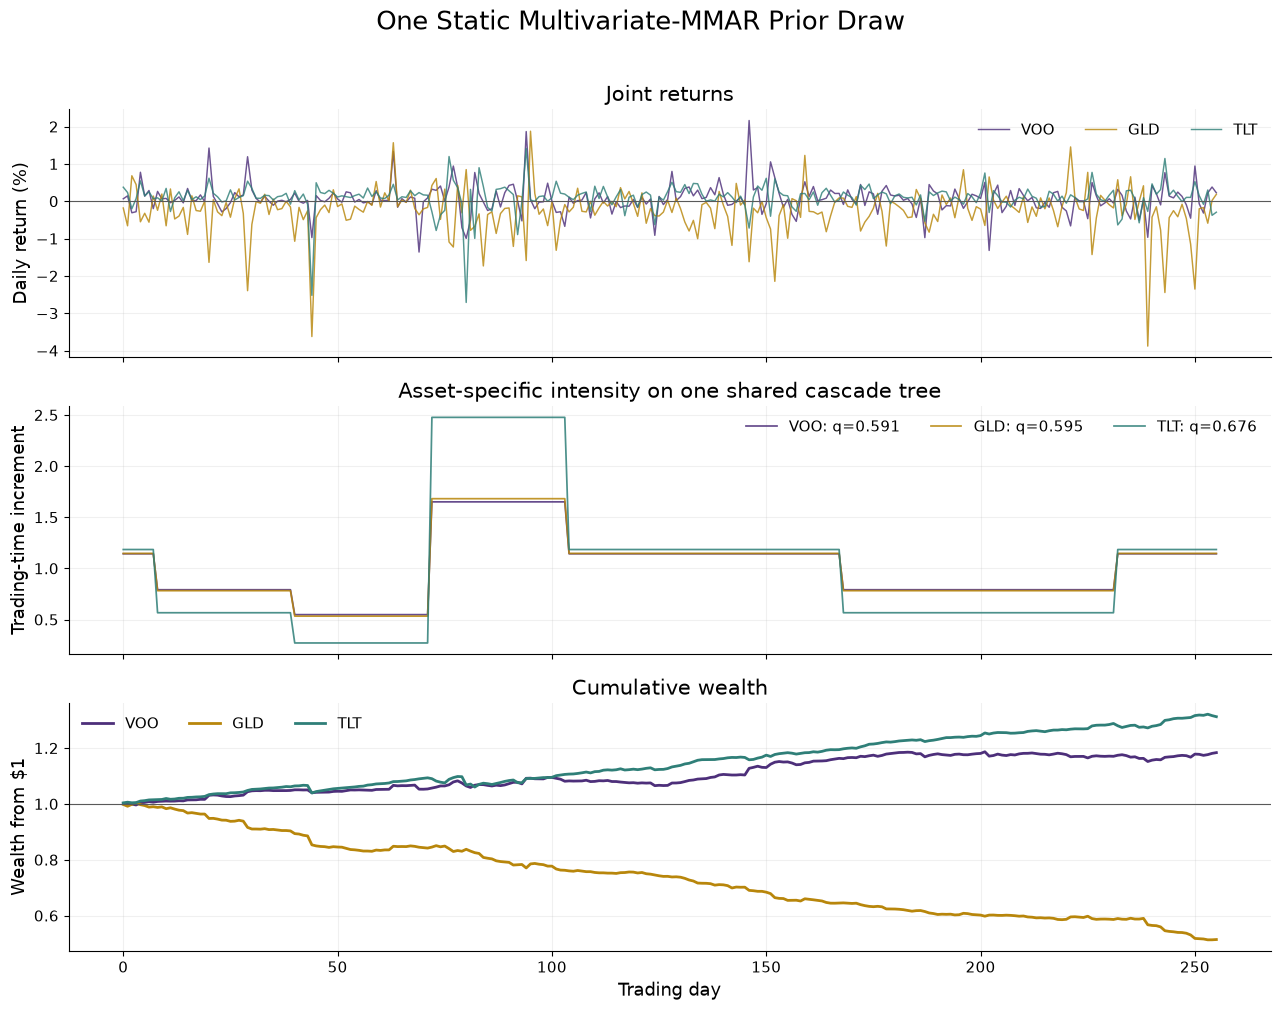

In [4]:
prior_draws = model.simulate(4_000, seed=42, prior=PRIOR)
prior_returns = prior_draws["returns"]

fig = plots.plot_example_paths(prior_draws, assets=ASSETS)
_ = viz.save_figure(fig, "01_example_joint_prior_path.png", FIGURES_DIR)

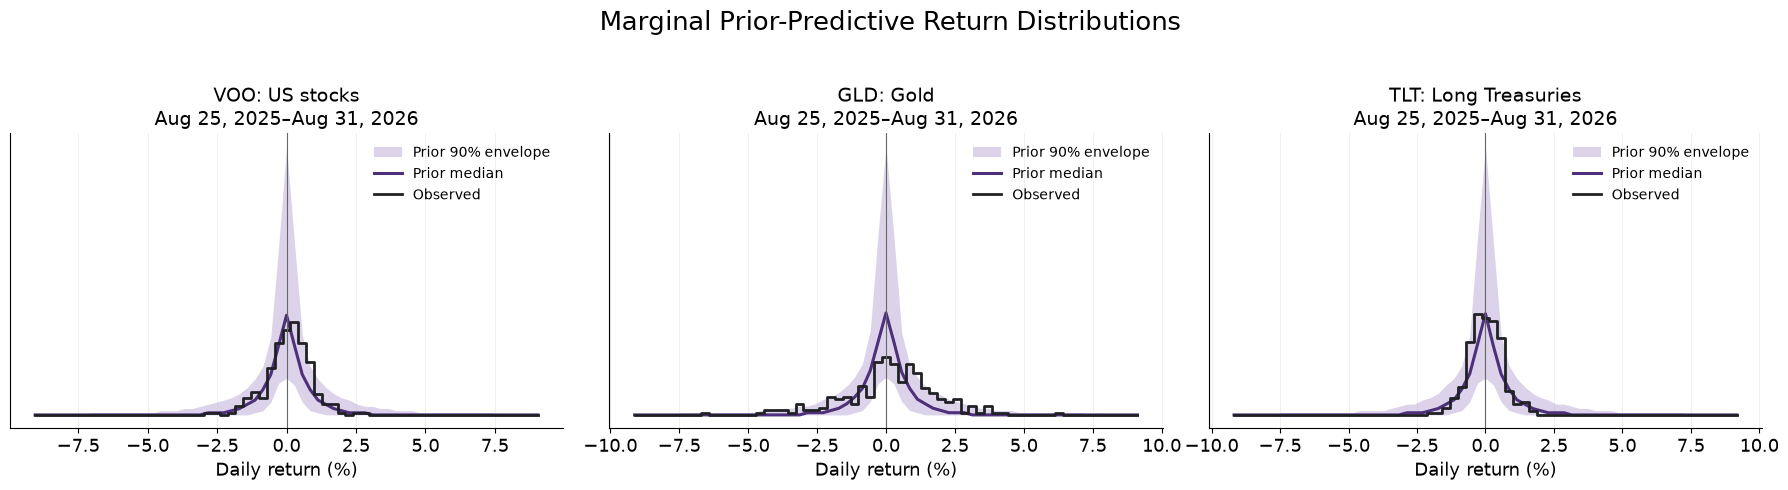

In [5]:
fig = plots.plot_marginal_return_envelopes(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "02_marginal_return_envelopes.png", FIGURES_DIR)

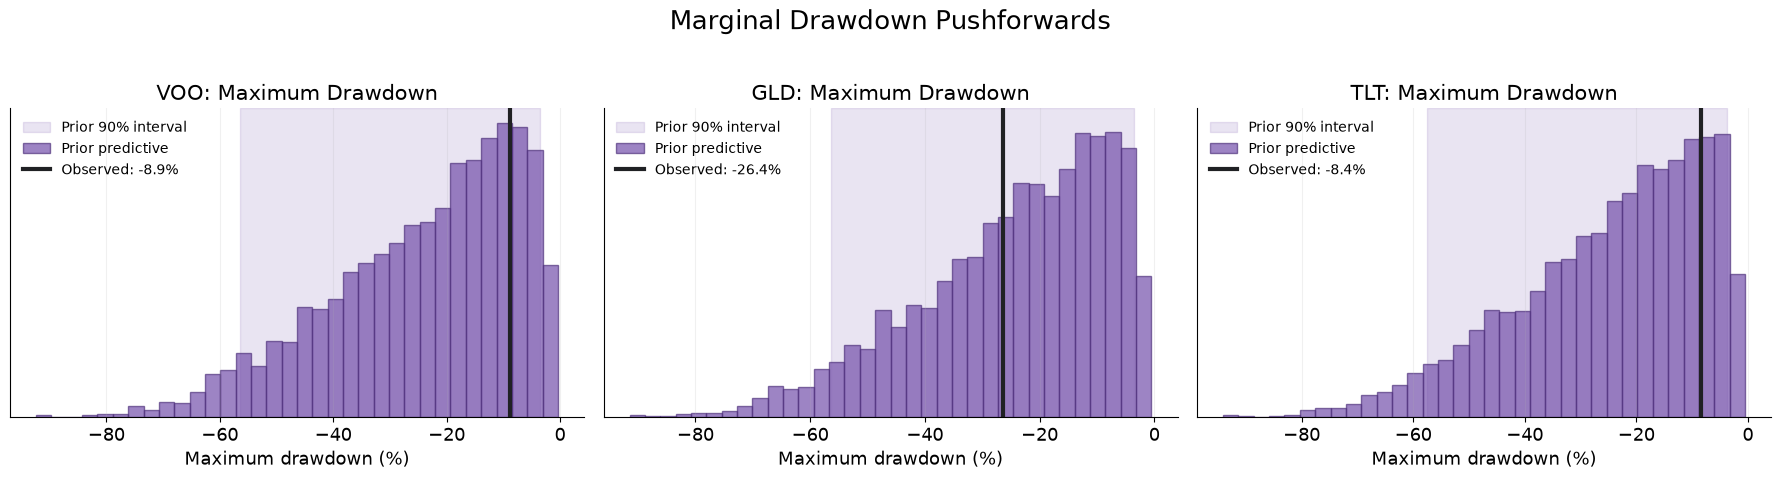

In [6]:
fig = plots.plot_marginal_drawdowns(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "03_marginal_drawdown_checks.png", FIGURES_DIR)

In [7]:
marginal_table = stats.marginal_pushforward_table(prior_returns, observed_window, assets=ASSETS)
marginal_table.style.format(precision=2)

,asset,stat,observed_pct,prior_q05_pct,prior_q95_pct,inside_prior_interval
0,VOO,mean_pct,0.08,-0.29,0.29,True
1,VOO,avg_abs_return_pct,0.61,0.26,1.52,True
2,VOO,volatility_pct,0.80,0.40,2.41,True
3,VOO,q01_pct,-1.89,-6.59,-0.97,True
4,VOO,q05_pct,-1.39,-3.40,-0.44,True
5,VOO,expected_shortfall_5_pct,-1.77,-5.61,-0.85,True
6,VOO,max_drawdown_pct,-8.90,-56.47,-3.62,True
7,GLD,mean_pct,0.12,-0.29,0.29,True
8,GLD,avg_abs_return_pct,1.30,0.26,1.54,True
9,GLD,volatility_pct,1.81,0.40,2.35,True


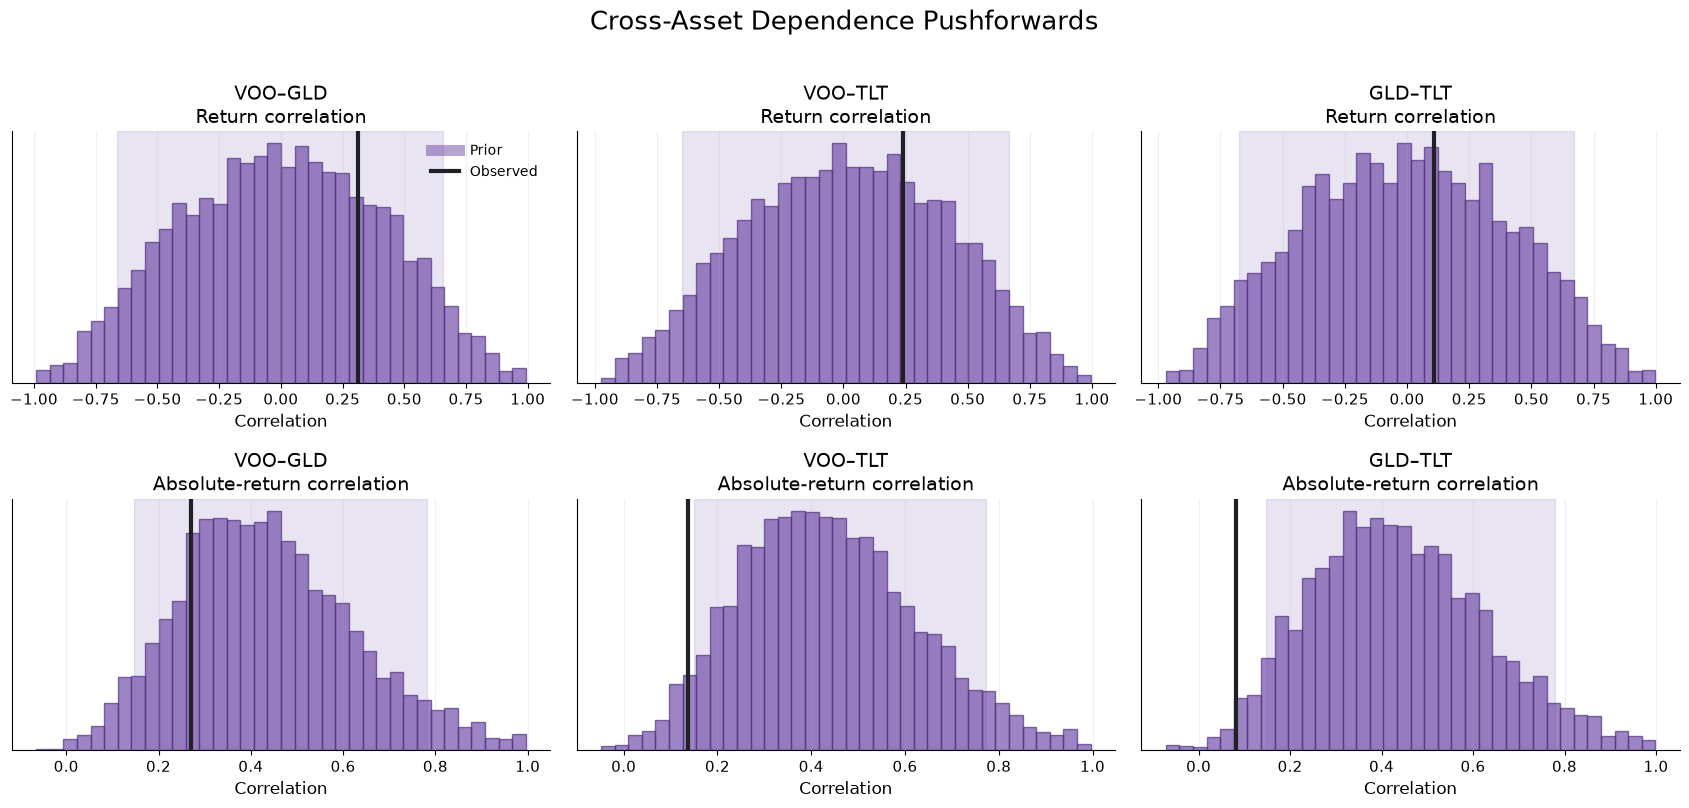

In [8]:
fig = plots.plot_dependence_pushforwards(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "04_cross_asset_dependence.png", FIGURES_DIR)

In [9]:
dependence_table = stats.dependence_pushforward_table(prior_returns, observed_window, assets=ASSETS)
dependence_table.style.format(precision=2)

,pair,stat,observed,prior_q05,prior_q95,unit,inside_prior_90pct_interval
0,VOO–GLD,return_correlation,0.31,-0.66,0.66,correlation,True
1,VOO–GLD,absolute_return_correlation,0.27,0.15,0.78,correlation,True
2,VOO–GLD,joint_downside_probability,1.56,0.00,2.34,%,True
3,VOO–TLT,return_correlation,0.24,-0.65,0.67,correlation,True
4,VOO–TLT,absolute_return_correlation,0.14,0.15,0.77,correlation,False
5,VOO–TLT,joint_downside_probability,1.17,0.00,2.34,%,True
6,GLD–TLT,return_correlation,0.11,-0.68,0.67,correlation,True
7,GLD–TLT,absolute_return_correlation,0.08,0.15,0.78,correlation,False
8,GLD–TLT,joint_downside_probability,0.00,0.00,2.73,%,True


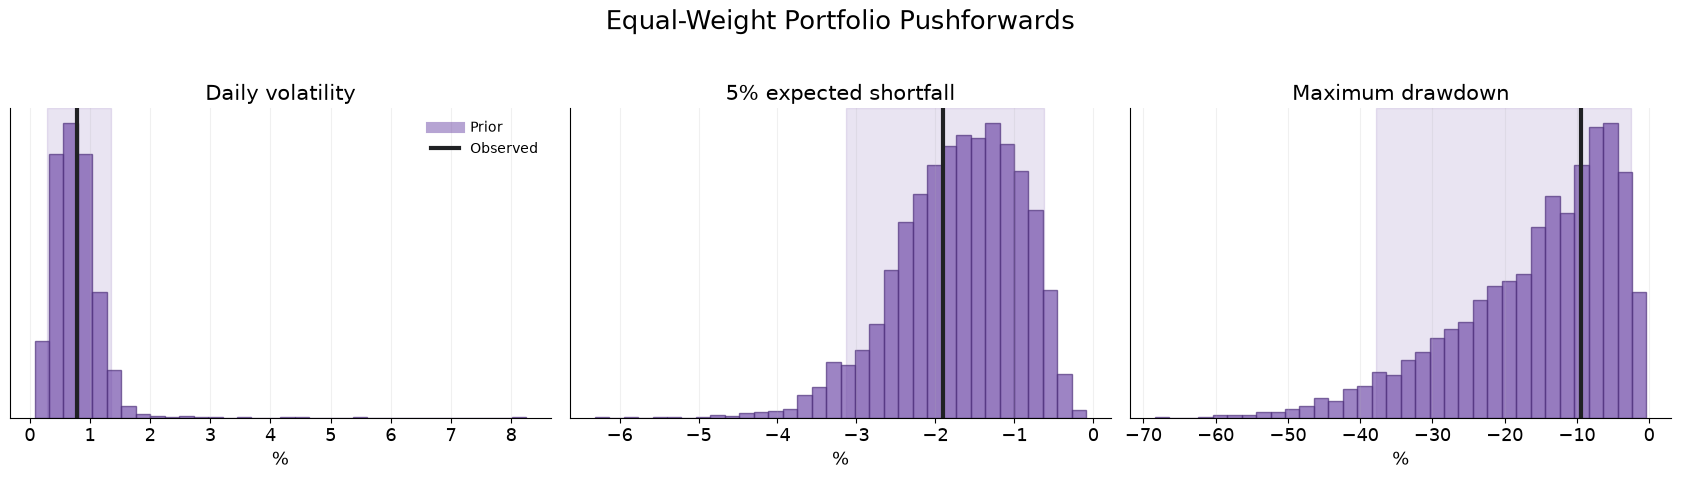

In [10]:
fig = plots.plot_equal_weight_portfolio_checks(prior_returns, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "05_equal_weight_portfolio_checks.png", FIGURES_DIR)

## 3. Amortized inference

The adapter enforces the updated prior bounds, including $2.05<\nu<12$, and valid partial correlations.
Retrain in the new checkpoint directory: earlier daily-cascade checkpoints do not match this model.

In [11]:
sigma_keys = tuple(f"sigma_bar_{asset}" for asset in ASSETS)
q_keys = tuple(f"q_{asset}" for asset in ASSETS)
adapter = bf.Adapter().split("sigma_bar", into=sigma_keys).split("q", into=q_keys)
for key, lower, upper in zip(sigma_keys, PRIOR.sigma_bar_low, PRIOR.sigma_bar_high):
    adapter.constrain(key, lower=lower, upper=upper)
for key, lower, upper in zip(q_keys, PRIOR.q_low, PRIOR.q_high):
    adapter.constrain(key, lower=lower, upper=upper)
adapter = (
    adapter
    .constrain("nu", lower=PRIOR.nu_low, upper=PRIOR.nu_high)
    .constrain("correlation_partials", lower=-1.0, upper=1.0)
    .concatenate(("mu", *sigma_keys, *q_keys, "nu", "correlation_partials"), into="inference_variables")
    .rename("returns", "summary_variables")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    summary_network=bf.networks.FusionTransformer(),
    inference_network=bf.networks.CouplingFlow(transform="spline", depth=4),
    standardize="all",
    checkpoint_filepath=CHECKPOINT_DIR,
    save_best_only=True,
)

In [12]:
training_data = model.training_data(100_000, prior=PRIOR)
validation_data = model.training_data(100, prior=PRIOR)

In [13]:
history = workflow.fit_offline(
    data=training_data, 
    validation_data=validation_data, 
    epochs=100, 
    batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 28ms/step - loss: 16.5964 - val_loss: 15.1731
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 14.1663 - val_loss: 11.3973
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 9.0948 - val_loss: 6.2658
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 6.1860 - val_loss: 4.6388
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 5.1486 - val_loss: 3.7740
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.5305 - val_loss: 3.2195
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.1209 - val_loss: 2.9781
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 4.1364 - val_loss: 2.9694
Epoch 9/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.4923 - val_loss: 2.5445
Epoch 10/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 3.1687 - val_loss: 2.0620
Epoch 11/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 2.9343 - val_loss: 1.7790
Epoch 12/100
782/782 ━━━━

INFO:bayesflow:Training completed in 15.05 minutes.
INFO:bayesflow:Training is now finished.
You can find the trained approximator at 'checkpoints/multivariate_clustered/model.keras'.
To restore it:
Via the workflow: workflow.load_approximator()
Standalone: approximator = keras.saving.load_model("checkpoints/multivariate_clustered/model.keras")


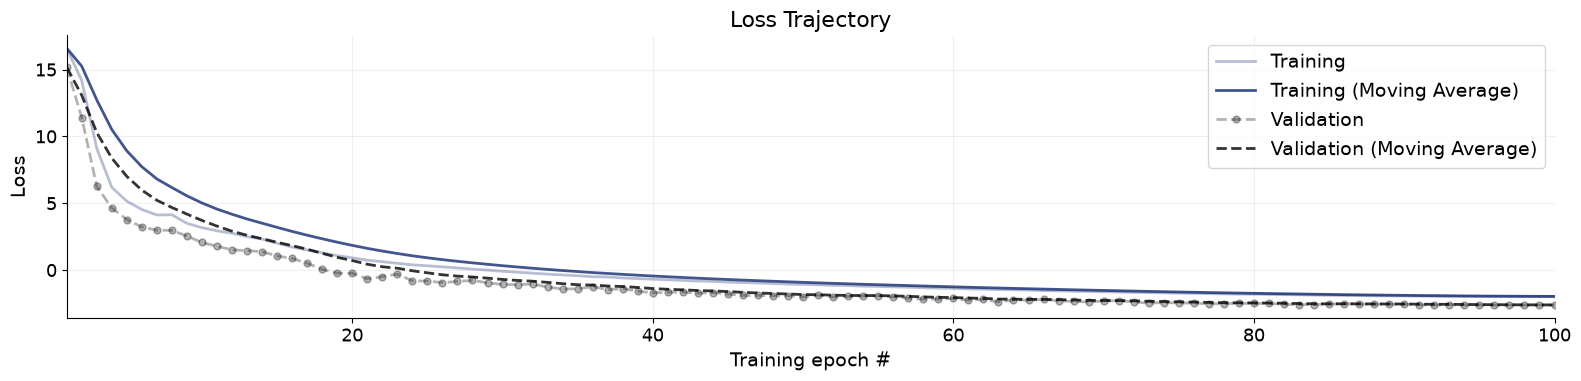

In [14]:
fig = bf.diagnostics.loss(history)
_ = viz.save_figure(fig, "06_training_loss.png", FIGURES_DIR)

## 4. Parameter recovery and calibration

In [15]:
test_data = model.training_data(300, prior=PRIOR)
test_parameters = model.stack_parameters(test_data)

validation_samples = model.stack_parameters(workflow.sample(
    conditions=test_data, 
    num_samples=1000
))

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 11.92 seconds.


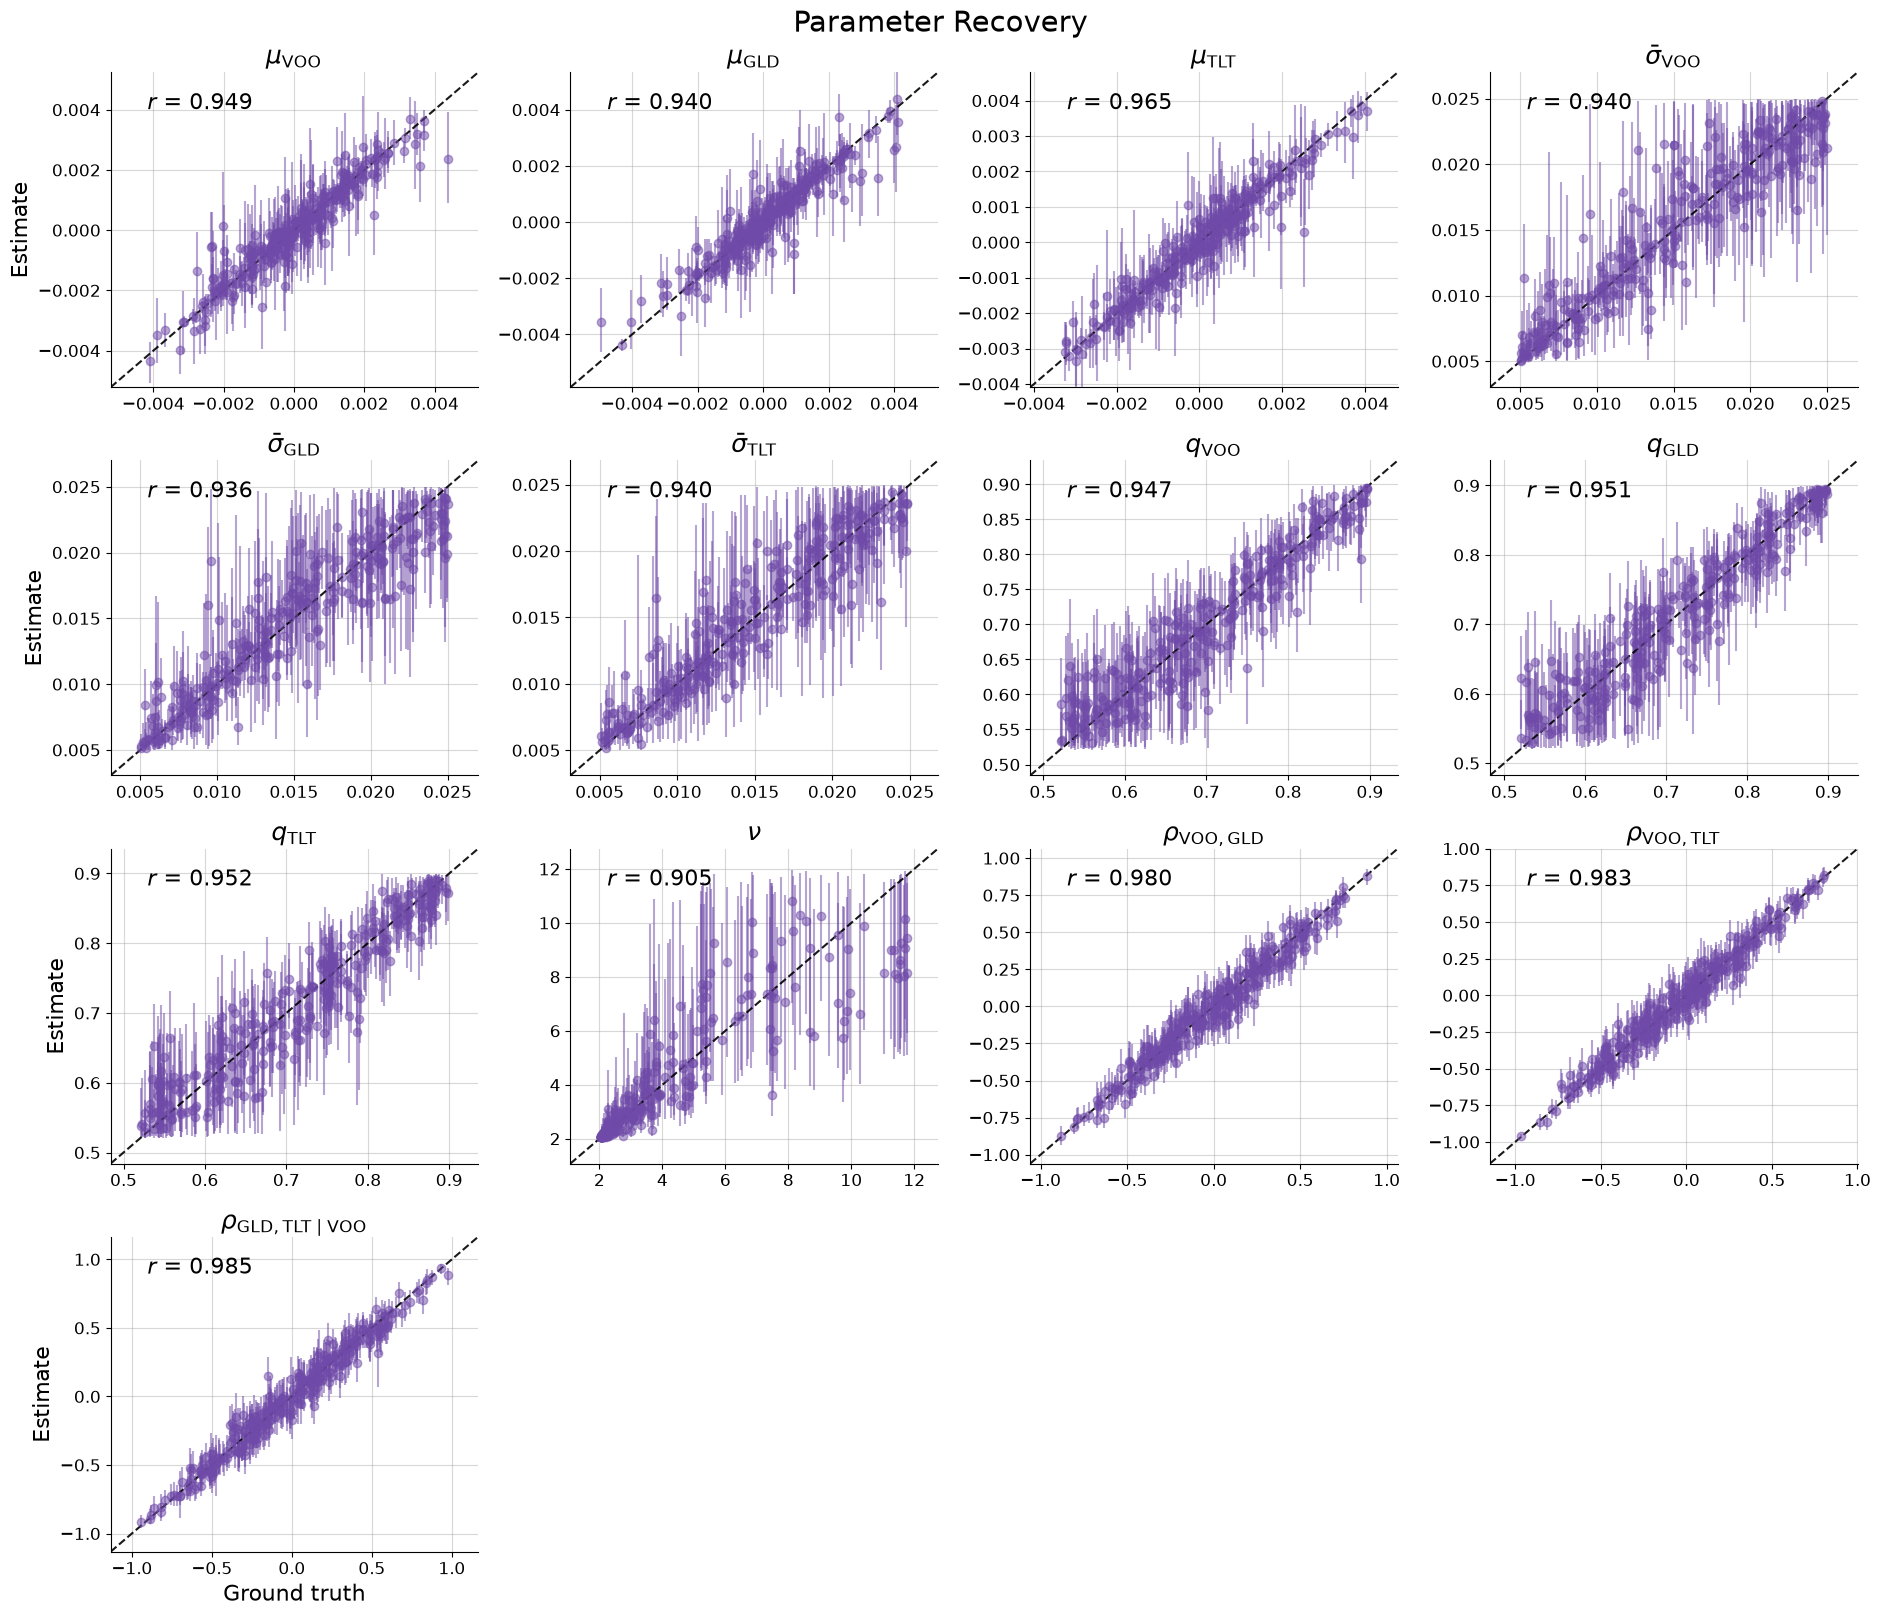

In [16]:
fig = viz.plot_recovery(validation_samples, test_parameters, model.PARAMETER_LABELS, grid=(4, 4), interval=0.92)
_ = viz.save_figure(fig, "07_parameter_recovery.png", FIGURES_DIR)

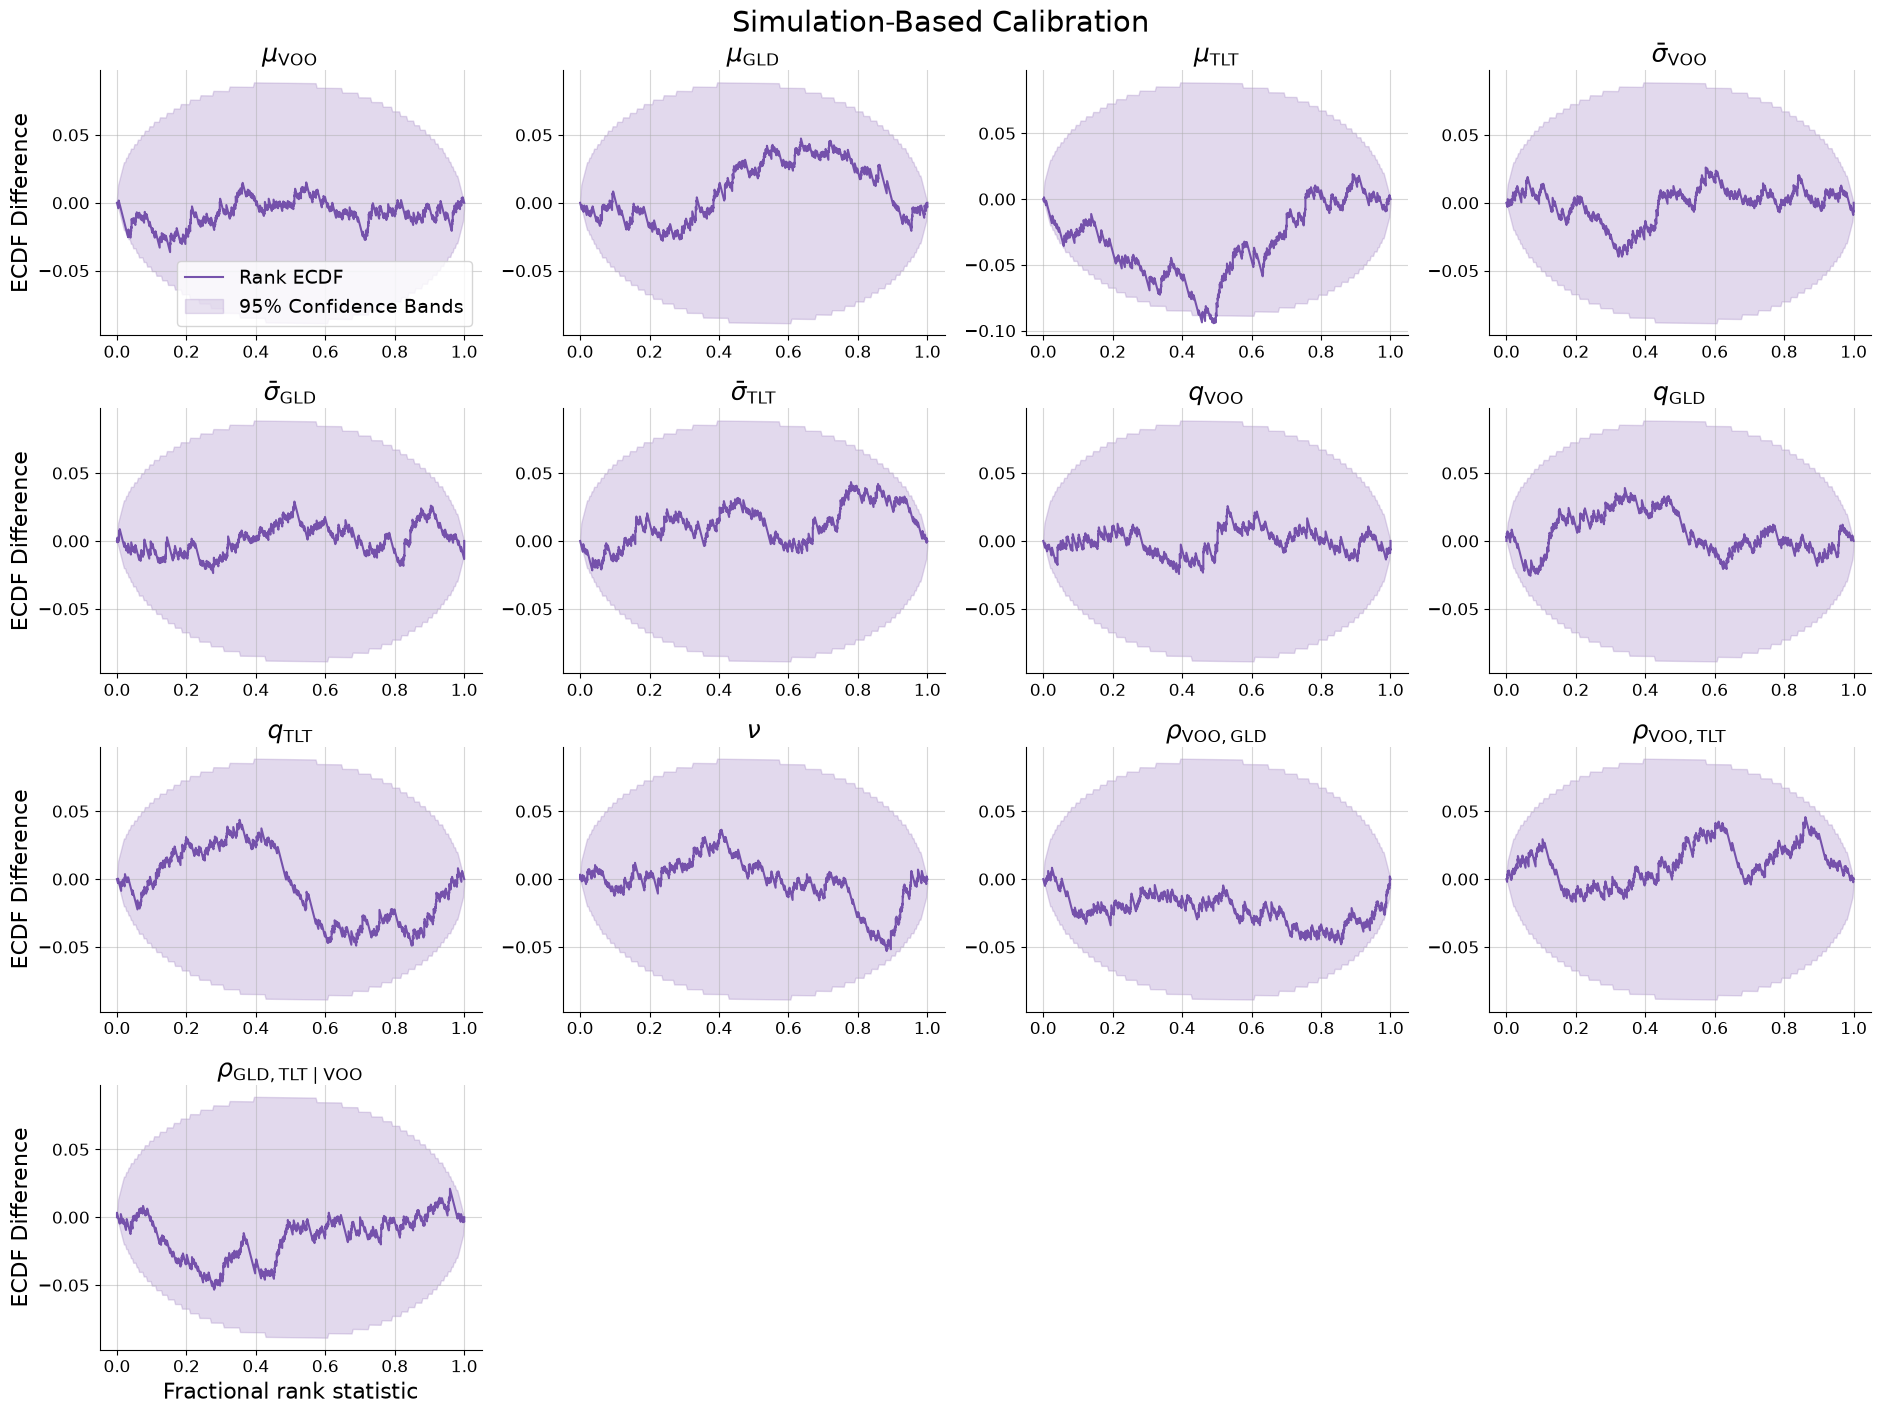

In [17]:
fig = viz.plot_calibration(validation_samples, test_parameters, model.PARAMETER_LABELS, grid=(4, 4))
_ = viz.save_figure(fig, "08_simulation_based_calibration.png", FIGURES_DIR)

## 5. Posterior predictive checks

Joint resimulations retain the learned cross-asset dependence. Shading: 68% and 92% predictive intervals.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 9.18 seconds.


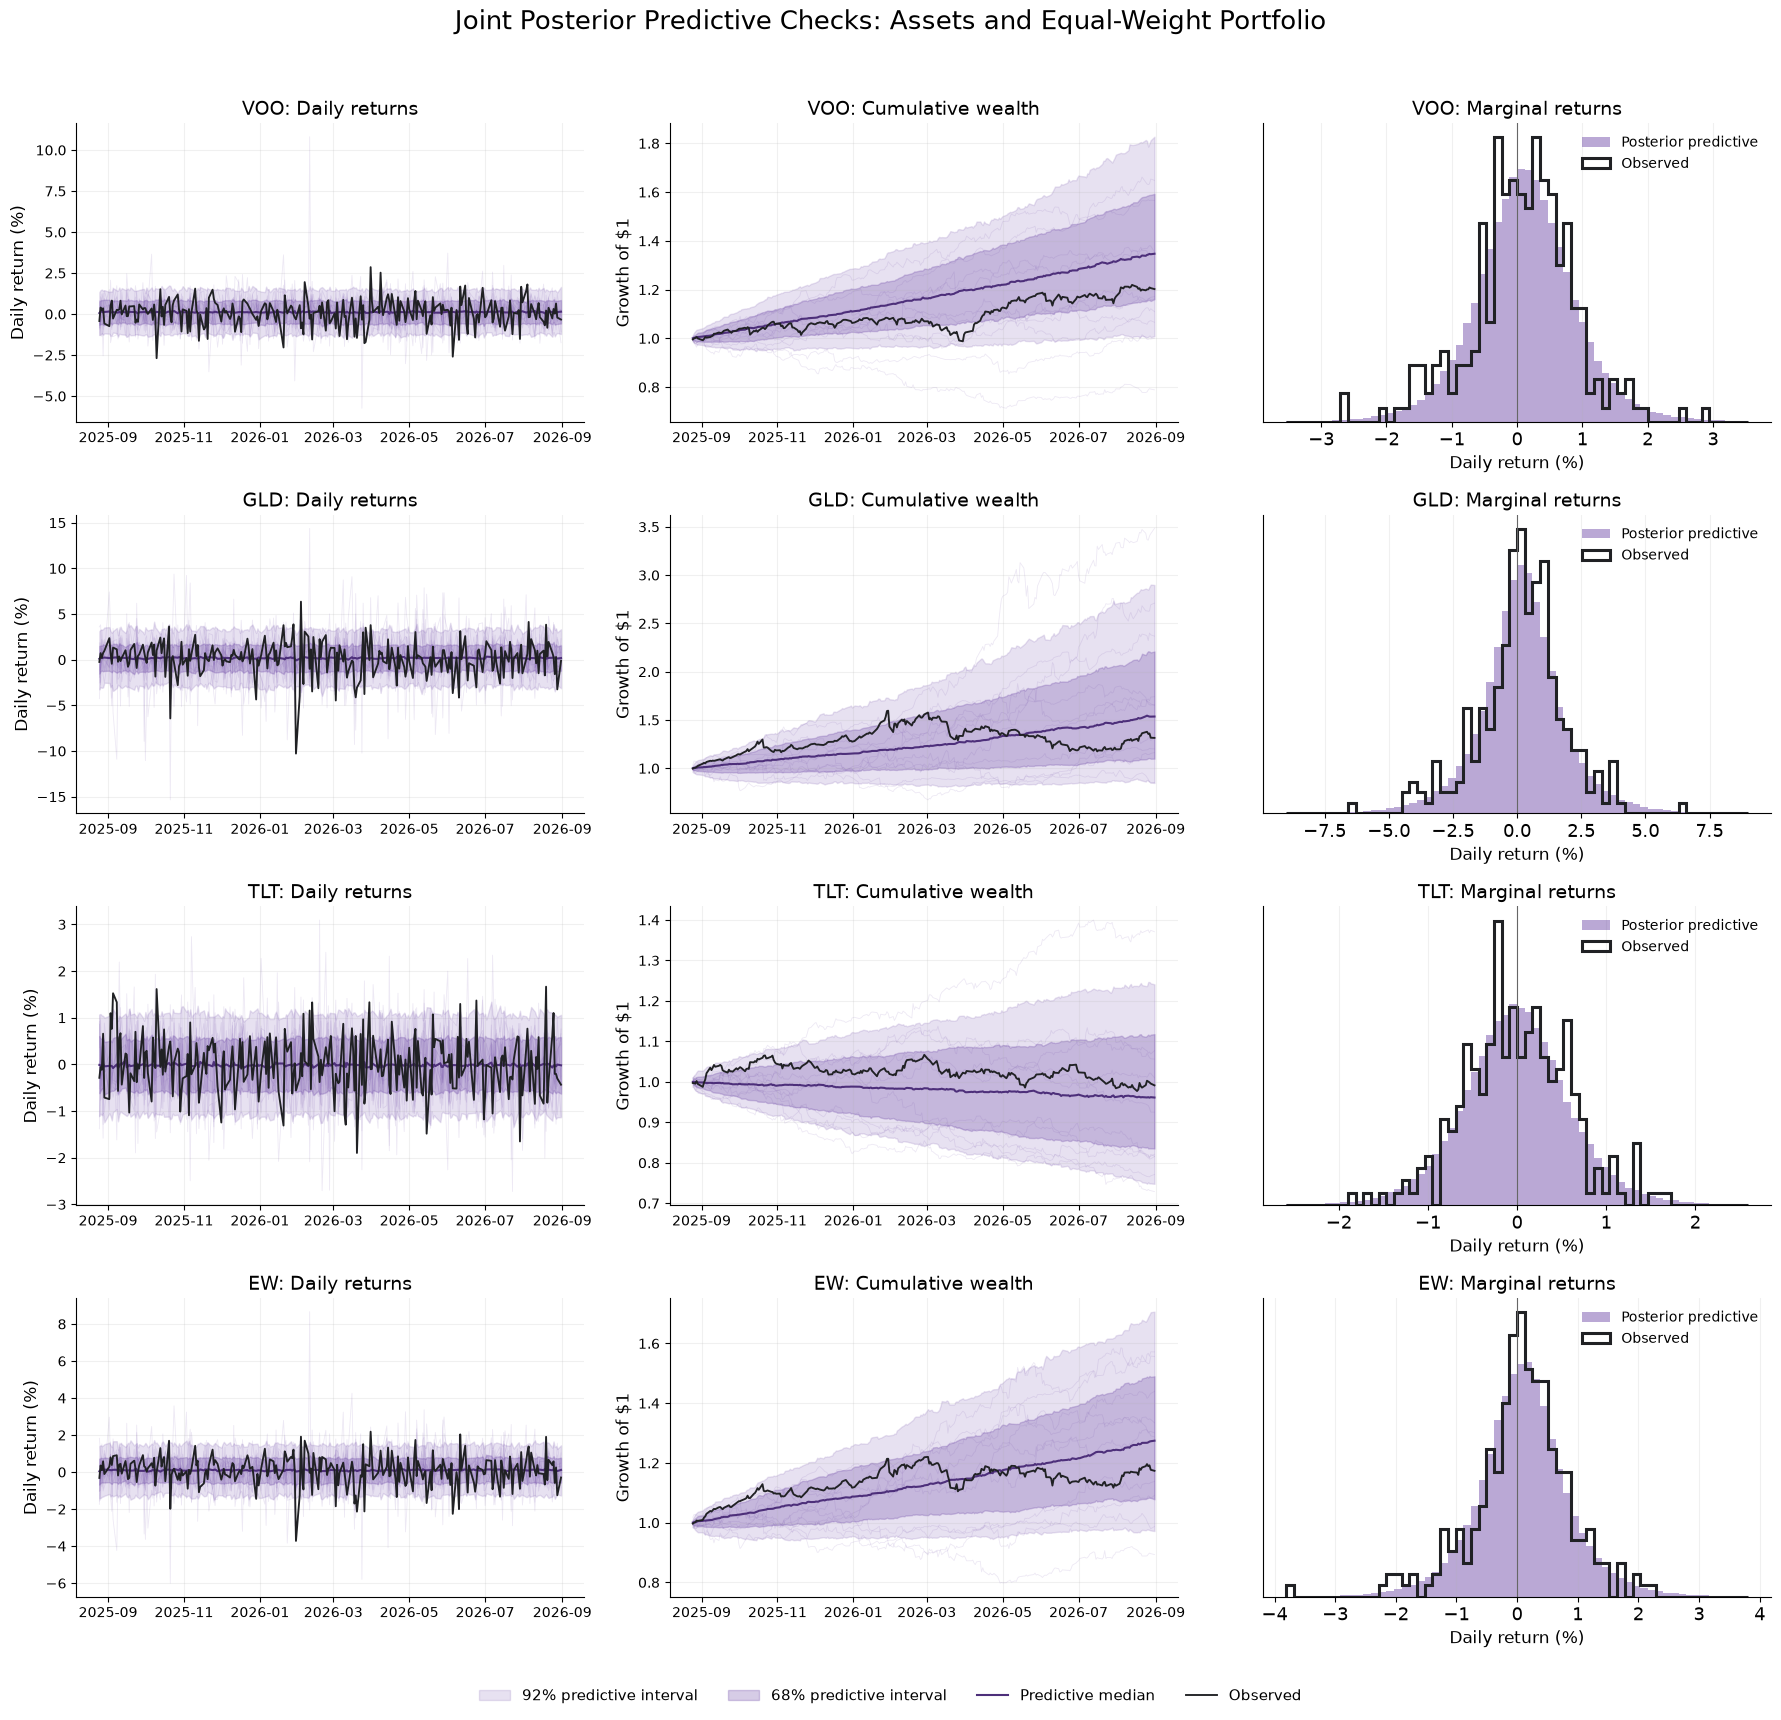

In [18]:
observed_posterior = workflow.sample(
    conditions={"returns": observed_window.to_numpy(dtype="float32")[None, ...]},
    num_samples=600, 
    batch_size=64
)
posterior_paths = model.posterior_resimulations(observed_posterior)[0]

fig = plots.plot_multivariate_posterior_predictive_checks(posterior_paths, observed_window, assets=ASSETS)
_ = viz.save_figure(fig, "09_posterior_predictive_checks.png", FIGURES_DIR)

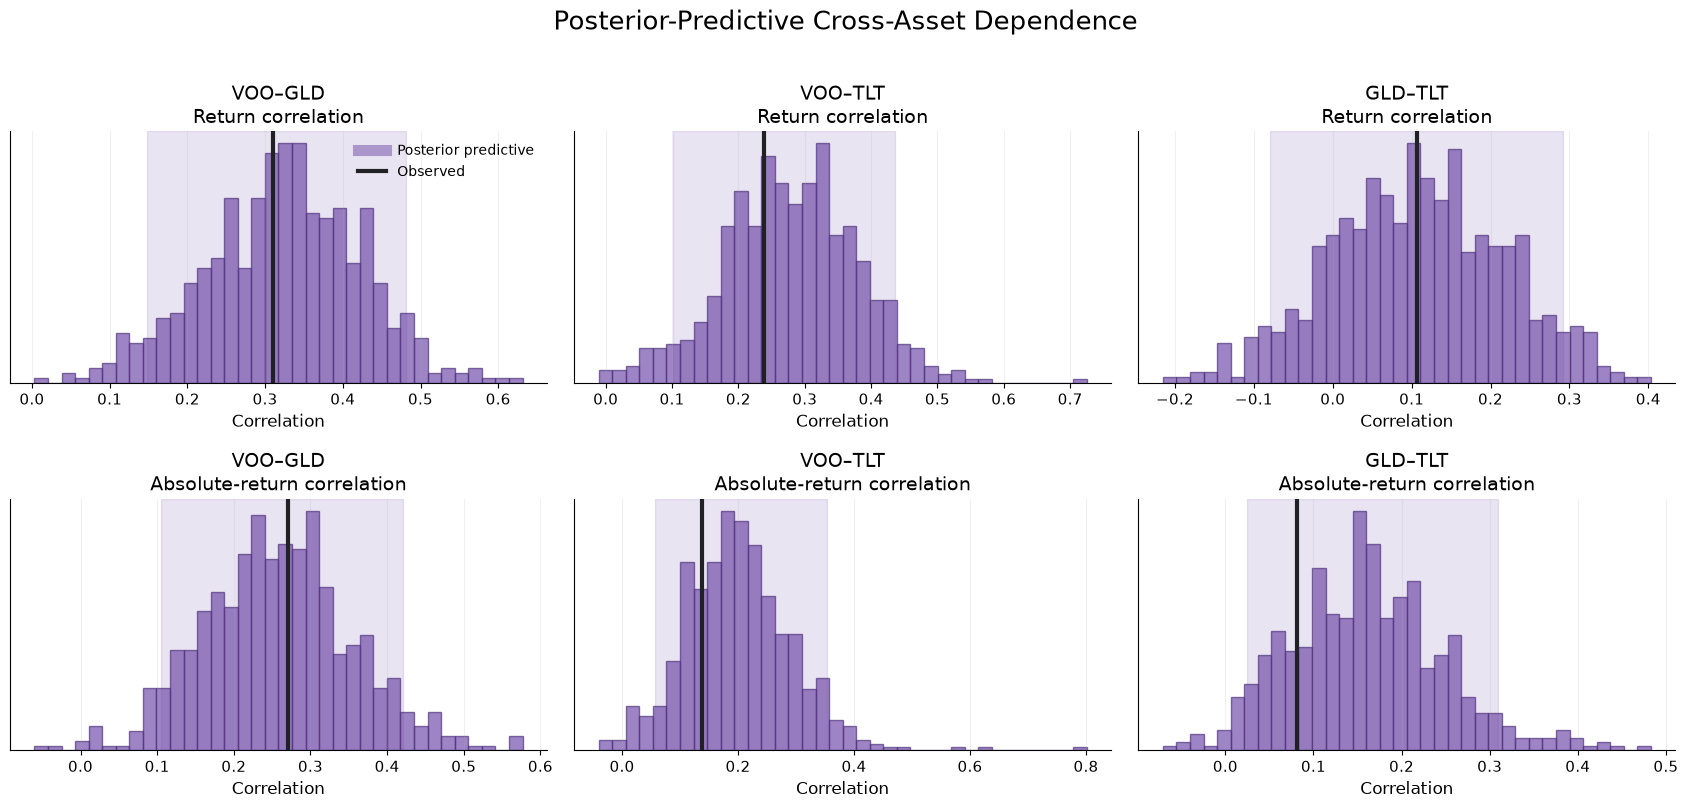

In [19]:
fig = plots.plot_dependence_pushforwards(
    posterior_paths, observed_window, assets=ASSETS,
    predictive_label="Posterior predictive", figure_title="Posterior-Predictive Cross-Asset Dependence",
)
_ = viz.save_figure(fig, "10_posterior_dependence_checks.png", FIGURES_DIR)

## 6. Amortized decisions

20-day VaR and ES versus historical simulation from the same trailing window. **EW** means daily-rebalanced
equal weights. Bands show posterior-parameter variation plus simulation noise, not realized-return intervals.
Forecast scenarios start fresh 256-day cascades; they do not filter the latest latent volatility state.

Summarizing:   0%|          | 0/3 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/3 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 16.11 seconds.


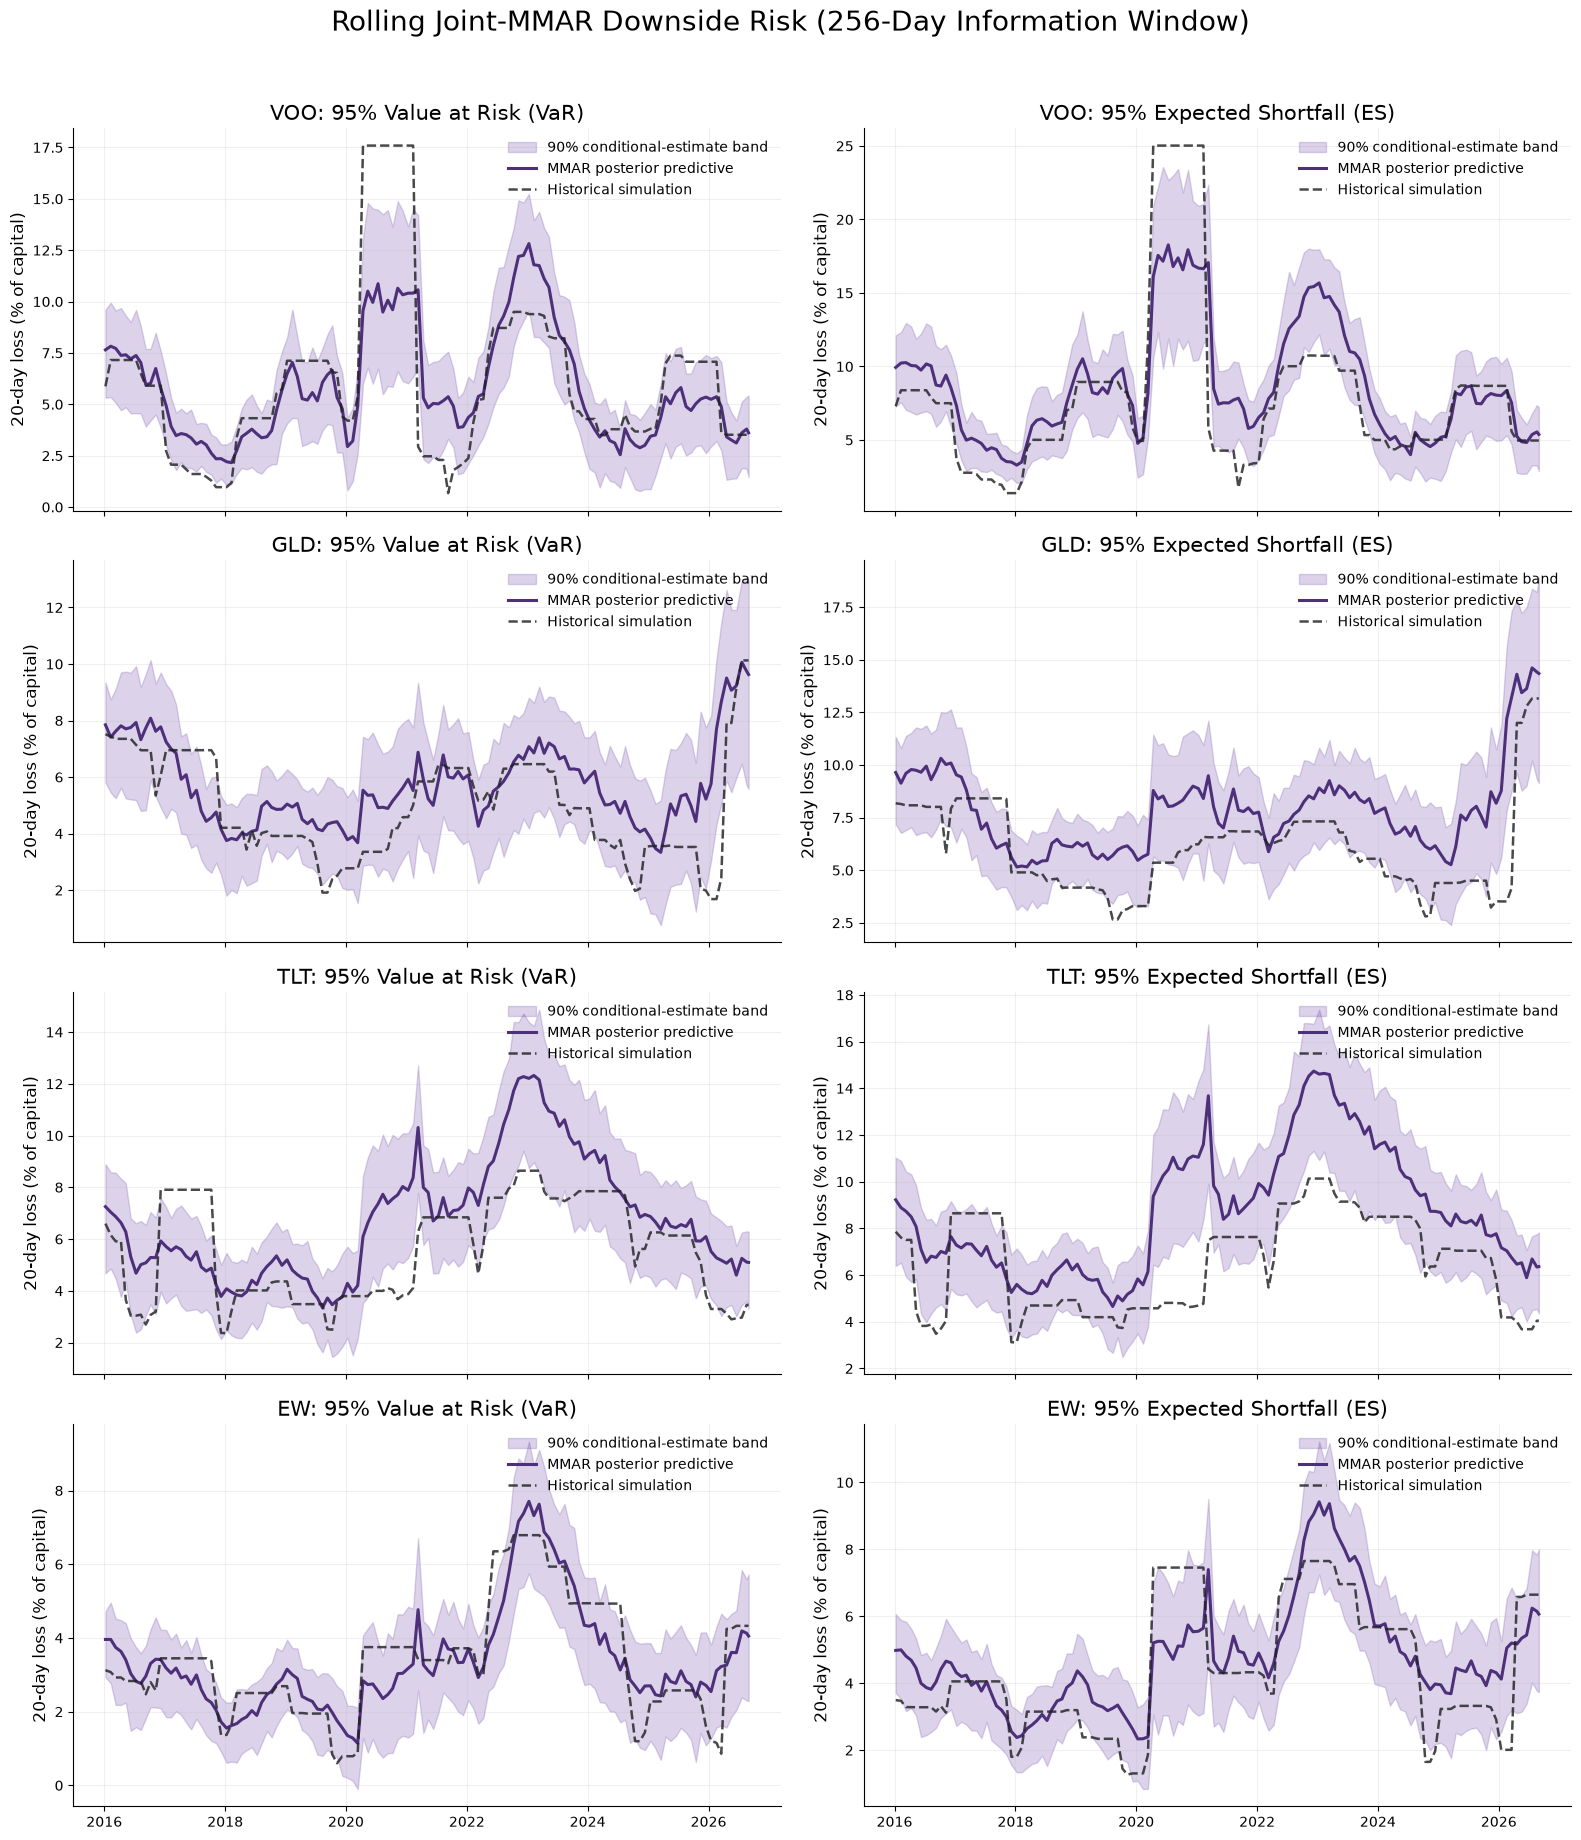

In [20]:
rolling_windows, rolling_metadata = decisions.joint_rolling_return_windows(observed_returns, step=21)
rolling_posteriors = workflow.sample(
    conditions={"returns": rolling_windows}, num_samples=500, batch_size=64
)

risk_table = decisions.multivariate_posterior_risk_table(
    rolling_posteriors, rolling_metadata, observed_returns,
    horizon=20, n_parameter_draws=160, n_replications=192
)

risk_table.to_csv(FIGURES_DIR / "rolling_risk.csv", index=False)

fig = plots.plot_multivariate_rolling_risk(risk_table, targets=(*ASSETS, "EW"))
_ = viz.save_figure(fig, "11_rolling_var_es.png", FIGURES_DIR)

### Posterior-driven allocation

Choose at close $t$; apply only the observed return at $t+1$. The long-only grid maximizes median
20-day return minus $0.75\,ES_{95}^{loss}$ and turnover costs, with a 1 bp no-trade hurdle.

Start with $1,000. Compare daily/21-day decisions against VOO buy-and-hold and a three-ETF
“All Weather” proxy (30% VOO, 15% GLD, 55% TLT). Initial purchases are free; later trades pay 0/5/20 bp
per unit of one-way turnover.

In [21]:
backtest_windows, backtest_metadata = decisions.joint_rolling_return_windows(observed_returns, step=1)
backtest_posteriors = workflow.sample(conditions={"returns": backtest_windows}, num_samples=96, batch_size=64)

allocation_grid = allocation.simplex_weight_grid(step=0.05, min_weight=0.05, max_weight=0.80)
terminal_scenarios = allocation.posterior_terminal_asset_scenarios(
    backtest_posteriors, 
    horizon=20,
    n_parameter_draws=64, 
    n_replications=8
)

backtest = allocation.run_posterior_allocation_backtest(
    observed_returns, backtest_metadata, terminal_scenarios, allocation_grid,
    initial_wealth=1000, rebalance_every=(1, 21), fee_bps=(0, 5, 20),
)

backtest_summary = allocation.allocation_backtest_summary(backtest, initial_wealth=1000)
backtest.to_csv(FIGURES_DIR / "allocation_daily.csv", index=False)
backtest_summary.to_csv(FIGURES_DIR / "allocation_summary.csv", index=False)

Summarizing:   0%|          | 0/42 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/42 [00:00<?, ?batch/s]

INFO:bayesflow:Sampling completed in 18.00 seconds.


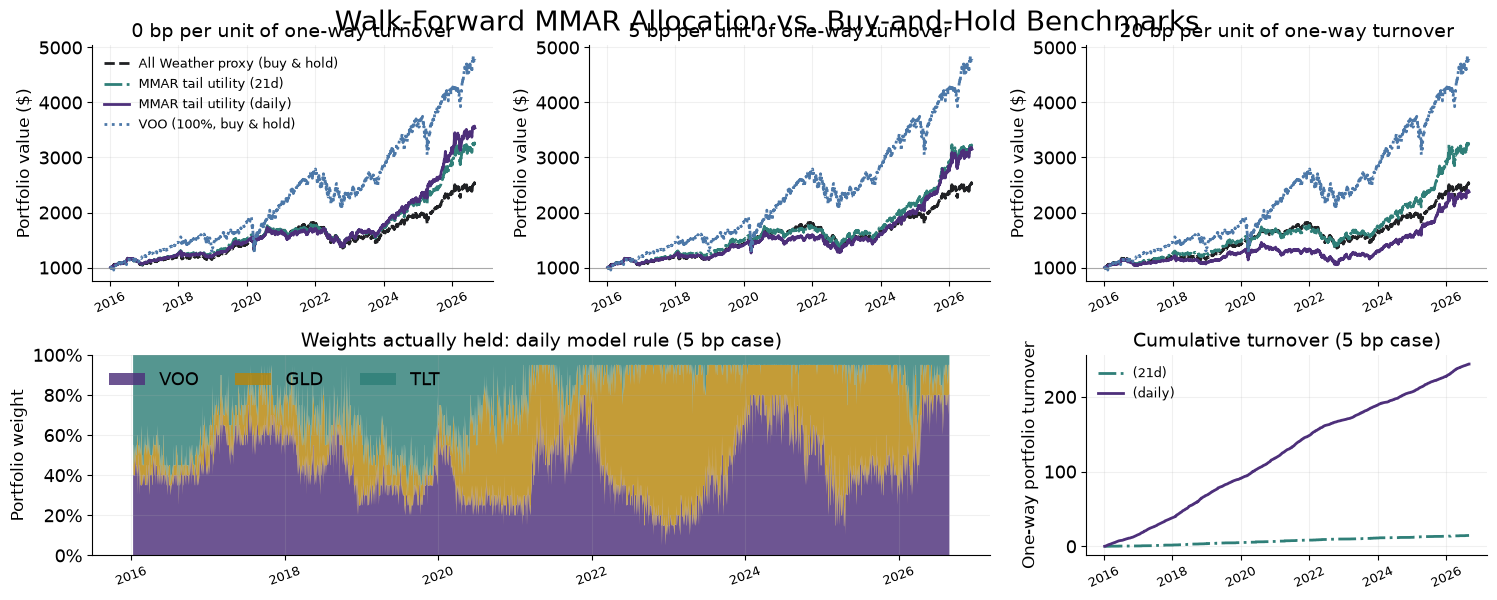

In [25]:
fig = plots.plot_model_allocation_backtest(backtest, initial_wealth=1000, figsize=(18, 6))
_ = viz.save_figure(fig, "12_model_allocation_backtest.png", FIGURES_DIR)

In [26]:
backtest_summary.pivot(index="strategy", columns="fee_bps", values="final_wealth").round(2)

fee_bps,0.0,5.0,20.0
strategy,,,
All Weather proxy (buy & hold),2507.00,2507.00,2507.00
MMAR tail utility (21d),3233.63,3197.06,3234.77
MMAR tail utility (daily),3536.67,3151.14,2373.74
"VOO (100%, buy & hold)",4774.62,4774.62,4774.62
